# SpudCell Simulation

**System Overview:**
- Phi29 DNA polymerase genome replication
- αHL (alpha-hemolysin) pore formation
- GFP reporter expression
- Resource-limited dynamics
- 5 generations × 12 hours each
- Mechanical extrusion between generations

**Modeling limitation:** the manuscript reports the experimental schedule and many starting concentrations, but not a complete identifiable set of kinetic constants. Rate constants here are therefore phenomenological starting values, not fitted biochemical constants.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, replace
from scipy.integrate import solve_ivp

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

import ipywidgets as widgets
from IPython.display import display, clear_output


## State Variables (9 Species)

\[
y=(D,M_A,A,M_G,G,R,L,F,C)
\]

**Genome & Transcripts:**
- **D** (nM): Effective replicable genome-template concentration
  * Coarse-grained 7-plasmid genome
  * Replicated by Phi29 DNA polymerase

- **M_A** (a.u.): αHL mRNA concentration
  * Translated from D by host machinery
  * Rate depends on resource availability
  
- **M_G** (a.u.): GFP mRNA concentration
  * Reporter gene transcript
  * Indicates transcriptional activity

**Proteins & Complexes:**
- **A** (nM): Functional membrane αHL
  * Formed from M_A by translation
  * Creates pores for resource transport
  * Enables feeder fusion
  
- **G** (nM-equivalent): Mature GFP fluorescence
  * Functional reporter protein
  * Indicates gene expression success

**Cellular Resources:**
- **R** (normalized): Reaction-resource pool
  * ATP, amino acids, ribosomes
  * Consumed by transcription/translation
  * Replenished by feeder fusion
  
- **L** (relative): Membrane lipid
  * Grows during each generation
  * Resets after extrusion
  * Carries capacity limit

**External Components:**
- **F** (nM): Feeder pool available in current generation
  * Liposomes containing resources
  * αHL-dependent fusion required
  * *Supply determines maximum growth*
  
- **C** (a.u.): Cumulative fusion counter
  * Tracks total feeding events
  * Used as fitness proxy
  * Indicates resource acquisition

**Key Insight:** All processes compete for the same limited resource pool R!

The seven-plasmid genome is coarse-grained as one effective template pool because plasmid-specific kinetic constants are not supplied.

In [2]:
@dataclass(frozen=True)
class Params:
    generation_h: float = 12.0
    n_generations: int = 5
    initial_genome_nM: float = 2.5
    initial_lipid_mM: float = 1.0
    feeder_lipid_mM: float = 2.0

    k_rep: float = 2.2
    K_D: float = 2.0
    K_R: float = 0.25
    k_loss: float = 0.015

    k_tx_A: float = 1.35
    k_tx_G: float = 1.05
    d_mA: float = 0.32
    d_mG: float = 0.28

    k_tl_A: float = 0.70
    k_tl_G: float = 0.85
    d_A: float = 0.055
    d_G: float = 0.010

    k_fus: float = 0.50
    K_A: float = 1.2
    K_F: float = 0.35
    k_R_feed: float = 1.30
    k_L_feed: float = 0.70

    gamma_rep: float = 0.030
    gamma_tx: float = 0.016
    gamma_tl: float = 0.022
    d_R: float = 0.035
    d_L: float = 0.002

    division_retention: float = 0.95
    mRNA_retention: float = 0.90
    protein_retention: float = 0.96
    resource_retention: float = 0.85
    lipid_reset: float = 1.0

P = Params()
P


Params(generation_h=12.0, n_generations=5, initial_genome_nM=2.5, initial_lipid_mM=1.0, feeder_lipid_mM=2.0, k_rep=2.2, K_D=2.0, K_R=0.25, k_loss=0.015, k_tx_A=1.35, k_tx_G=1.05, d_mA=0.32, d_mG=0.28, k_tl_A=0.7, k_tl_G=0.85, d_A=0.055, d_G=0.01, k_fus=0.5, K_A=1.2, K_F=0.35, k_R_feed=1.3, k_L_feed=0.7, gamma_rep=0.03, gamma_tx=0.016, gamma_tl=0.022, d_R=0.035, d_L=0.002, division_retention=0.95, mRNA_retention=0.9, protein_retention=0.96, resource_retention=0.85, lipid_reset=1.0)

## Parameter Guide

**Kinetic Constants:**
- `k_rep`: Phi29 DNA replication rate (1/h)
- `k_tx_A`, `k_tx_G`: Transcription rates for αHL, GFP
- `k_tl_A`, `k_tl_G`: Translation rates
- `k_fus`: Vesicle fusion rate (αHL-dependent)

**Michaelis Constants (µM):**
- `K_D`: DNA half-saturation
- `K_R`: Resource half-saturation
- `K_A`: αHL half-saturation
- `K_F`: Feeder half-saturation

**Retention Fractions:**
- `division_retention`: Genome retention after extrusion
- `mRNA_retention`: mRNA retention after extrusion
- `protein_retention`: Protein retention after extrusion
- `resource_retention`: Resource pool retention after extrusion

**Question:** Which parameter do you think most affects final DNA levels?

## ODE system

Genome replication is Phi29-dependent. Transcription and translation consume a shared resource pool. Fusion is αHL-dependent and replenishes both resource and membrane.

\[
v_{\rm rep}=\phi_{29}k_{\rm rep}\frac{R}{K_R+R}\frac{D}{K_D+D}
\]

\[
v_{\rm fus}=\phi_{\rm feed}k_{\rm fus}
\frac{A}{K_A+A}\frac{F}{K_F+F}
\]

Mechanical extrusion is represented by a discrete map at 12-hour generation boundaries.


In [3]:
STATE_NAMES = ["DNA", "mRNA_aHL", "aHL", "mRNA_GFP", "GFP",
               "resource", "lipid", "feeder", "fusion_counter"]

def rhs(t, y, p, phi29=True, feeding=True):
    D, mA, A, mG, G, R, L, F, C = np.maximum(y, 0.0)
    rf = R / (p.K_R + R)
    df = D / (p.K_D + D)

    v_rep = float(phi29) * p.k_rep * rf * df
    v_tx_A = p.k_tx_A * rf * df
    v_tx_G = p.k_tx_G * rf * df
    v_tl_A = p.k_tl_A * rf * mA
    v_tl_G = p.k_tl_G * rf * mG
    v_fus = float(feeding) * p.k_fus * A/(p.K_A + A) * F/(p.K_F + F)

    dD = v_rep - p.k_loss * D
    dmA = v_tx_A - p.d_mA * mA
    dA = v_tl_A - p.d_A * A
    dmG = v_tx_G - p.d_mG * mG
    dG = v_tl_G - p.d_G * G

    use = (p.gamma_rep*v_rep
           + p.gamma_tx*(v_tx_A + v_tx_G)
           + p.gamma_tl*(v_tl_A + v_tl_G))
    dR = -use + p.k_R_feed*v_fus - p.d_R*R
    dL = p.k_L_feed*v_fus - p.d_L*L
    dF = -v_fus
    dC = v_fus

    return [dD, dmA, dA, dmG, dG, dR, dL, dF, dC]

def division_map(y, p):
    z = y.copy()
    z[0] *= p.division_retention
    z[1] *= p.mRNA_retention
    z[2] *= p.protein_retention
    z[3] *= p.mRNA_retention
    z[4] *= p.protein_retention
    z[5] *= p.resource_retention
    z[6] = p.lipid_reset
    z[7] = 0.0
    return np.maximum(z, 0.0)

def initial_state(p):
    return np.array([
        p.initial_genome_nM, 0, 0, 0, 0,
        1.0, p.initial_lipid_mM, 0, 0
    ], dtype=float)

def simulate_cycle(p=P, phi29=True, feeding=True, feeder_scale=1.0, points=121):
    y = initial_state(p)
    times, states = [], []

    # Generation 0: 12 h pre-incubation without feeders
    te = np.linspace(0, p.generation_h, points)
    sol = solve_ivp(rhs, (te[0], te[-1]), y, t_eval=te,
                    args=(p, phi29, False), method="LSODA")
    times.extend(sol.t)
    states.extend(sol.y.T)
    y = sol.y[:, -1]

    # Generations 1-5
    for gen in range(1, p.n_generations + 1):
        y[7] = p.feeder_lipid_mM * feeder_scale if feeding else 0.0
        start = gen * p.generation_h
        end = (gen + 1) * p.generation_h
        te = np.linspace(start, end, points)

        sol = solve_ivp(rhs, (start, end), y, t_eval=te,
                        args=(p, phi29, feeding), method="LSODA")
        times.extend(sol.t[1:])
        states.extend(sol.y.T[1:])
        y = sol.y[:, -1]

        if gen < p.n_generations:
            y = division_map(y, p)

    df = pd.DataFrame(states, columns=STATE_NAMES)
    df.insert(0, "time_h", times)
    return df


## Simulate the four Figure 3-style conditions

### 🔬 Quick Prediction

**Before running the cell below, predict:**

Which condition will have:
1. Highest DNA at 60 hours? _____
2. Highest GFP at 60 hours? _____
3. Most membrane growth? _____
4. Lowest resource levels? _____

**Run the simulation**, then check your predictions!

💭 **Discussion:** Were your predictions correct? Why or why not?

## Running the Simulation

**Step 1:** The notebook will simulate 4 conditions (Figure 3):
- Φ29 + Feeding (wild-type)
- No Φ29 + Feeding
- Φ29 + No Feeding
- No Φ29 + No Feeding

**Step 2:** For each condition, the model:
- Simulates a 12-hour pre-incubation (generation 0)
- Simulates 5 generations with feeding
- Includes discrete extrusion events

**Step 3:** Results show:
- Genome replication over time
- mRNA expression patterns
- Protein accumulation
- Membrane growth
- Resource dynamics
- Cumulative fusion events

**Look for:** How the four conditions differ!

In [4]:
conditions = {
    "Phi29 + feeding": dict(phi29=True, feeding=True),
    "no Phi29 + feeding": dict(phi29=False, feeding=True),
    "Phi29 + no feeding": dict(phi29=True, feeding=False),
    "no Phi29 + no feeding": dict(phi29=False, feeding=False),
}

runs = {name: simulate_cycle(P, **kwargs) for name, kwargs in conditions.items()}

measurement_times = {3: 48, 4: 60, 5: 72}
rows = []
for name, df in runs.items():
    for generation, t in measurement_times.items():
        row = df.iloc[np.argmin(np.abs(df["time_h"].to_numpy() - t))]
        rows.append({"condition": name, "generation": generation,
                     **{s: row[s] for s in STATE_NAMES}})
summary = pd.DataFrame(rows)
summary.round(3)


,condition,generation,DNA,mRNA_aHL,aHL,mRNA_GFP,GFP,resource,lipid,feeder,fusion_counter
0,Phi29 + feeding,3,50.669,3.216,28.013,2.868,56.945,0.605,2.351,0.0,6.000
1,Phi29 + feeding,4,59.285,3.220,30.364,2.873,71.187,0.583,2.351,0.0,8.000
2,Phi29 + feeding,5,66.154,3.222,31.519,2.875,83.300,0.570,2.351,0.0,10.000
3,no Phi29 + feeding,3,1.098,1.414,15.538,1.261,34.962,2.538,2.351,0.0,6.000
4,no Phi29 + feeding,4,0.871,1.223,14.952,1.091,39.858,2.832,2.351,0.0,8.000
5,no Phi29 + feeding,5,0.692,1.043,13.660,0.931,42.645,3.065,2.351,0.0,9.999
6,Phi29 + no feeding,3,6.494,0.000,0.576,0.000,3.918,0.000,0.976,0.0,0.000
7,Phi29 + no feeding,4,5.153,0.000,0.286,0.000,3.336,0.000,0.976,0.0,0.000
8,Phi29 + no feeding,5,4.089,0.000,0.142,0.000,2.841,0.000,0.976,0.0,0.000
9,no Phi29 + no feeding,3,1.098,0.018,1.074,0.017,6.193,0.002,0.976,0.0,0.000


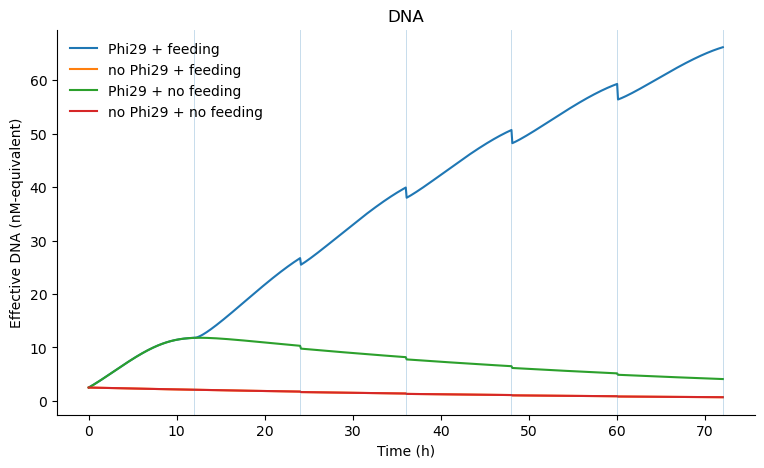

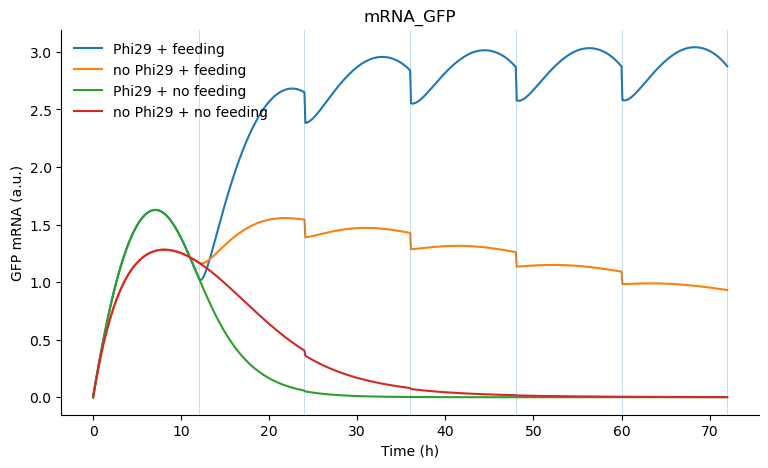

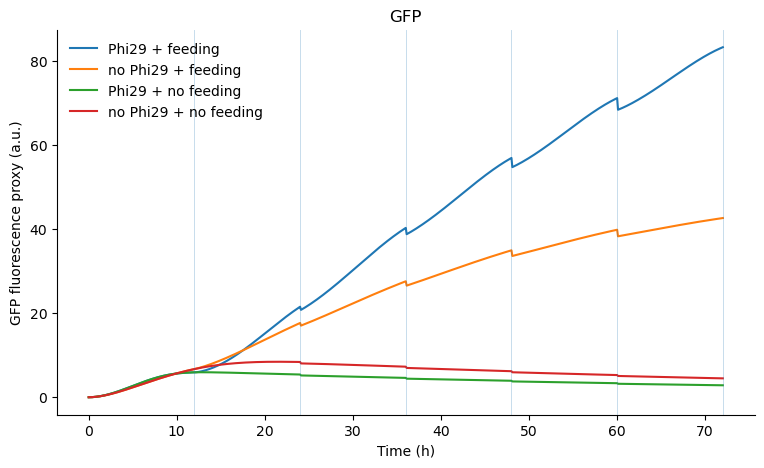

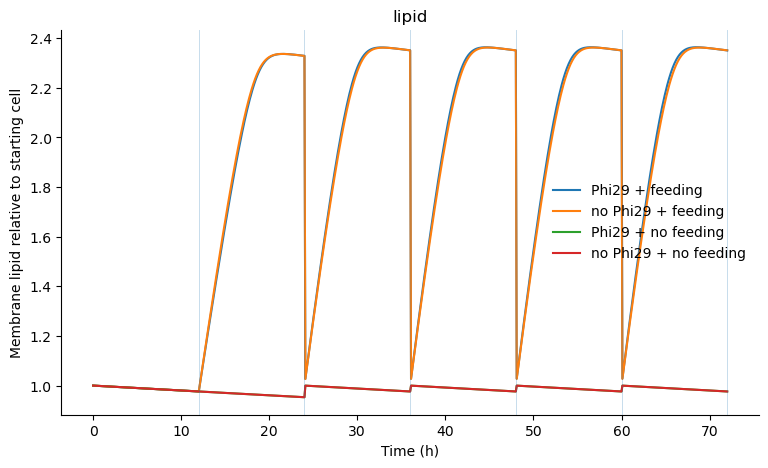

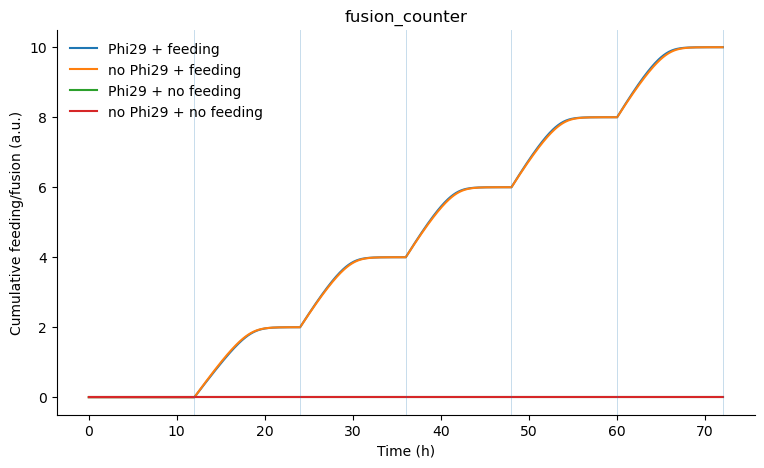

In [14]:
def plot_state(state, ylabel=None):
    fig, ax = plt.subplots()
    for name, df in runs.items():
        ax.plot(df["time_h"], df[state], label=name)
    for boundary in [12, 24, 36, 48, 60, 72]:
        ax.axvline(boundary, linewidth=0.7, alpha=0.25)
    ax.set_xlabel("Time (h)")
    ax.set_ylabel(ylabel or state)
    ax.set_title(state)
    ax.legend(frameon=False)
    plt.show()

plot_state("DNA", "Effective DNA (nM-equivalent)")
plot_state("mRNA_GFP", "GFP mRNA (a.u.)")
plot_state("GFP", "GFP fluorescence proxy (a.u.)")
plot_state("lipid", "Membrane lipid relative to starting cell")
plot_state("fusion_counter", "Cumulative feeding/fusion (a.u.)")


## Interactive parameter explorer

Use the sliders below to change the most biologically interpretable parameters.  
The simulation and endpoint table update automatically after you release a slider.

- **Replication:** `k_rep`
- **αHL expression:** `k_tx_A`
- **Fusion:** `k_fus`
- **Resource replenishment:** `k_R_feed`
- **Feeder amount:** `feeder_scale`
- **Genome retention after extrusion:** `division_retention`

The **Reset** button restores the notebook defaults.

In [6]:
# Interactive exploration of the core model
PARAMETER_HELP = {
    "k_rep": "Phi29-dependent DNA replication rate",
    "k_tx_A": "αHL transcription rate",
    "k_fus": "αHL-dependent feeder fusion rate",
    "k_R_feed": "Resource replenishment per fusion event",
    "division_retention": "Fraction of DNA retained after extrusion",
}

k_rep_slider = widgets.FloatSlider(
    value=P.k_rep, min=0.2, max=5.0, step=0.1,
    description="k_rep", continuous_update=False,
    readout_format=".2f", style={"description_width": "95px"},
    layout=widgets.Layout(width="420px")
)
k_tx_A_slider = widgets.FloatSlider(
    value=P.k_tx_A, min=0.1, max=3.0, step=0.05,
    description="k_tx_A", continuous_update=False,
    readout_format=".2f", style={"description_width": "95px"},
    layout=widgets.Layout(width="420px")
)
k_fus_slider = widgets.FloatSlider(
    value=P.k_fus, min=0.02, max=1.5, step=0.02,
    description="k_fus", continuous_update=False,
    readout_format=".2f", style={"description_width": "95px"},
    layout=widgets.Layout(width="420px")
)
k_R_feed_slider = widgets.FloatSlider(
    value=P.k_R_feed, min=0.1, max=3.0, step=0.05,
    description="k_R_feed", continuous_update=False,
    readout_format=".2f", style={"description_width": "95px"},
    layout=widgets.Layout(width="420px")
)
feeder_scale_slider = widgets.FloatSlider(
    value=1.0, min=0.0, max=2.0, step=0.05,
    description="feeder scale", continuous_update=False,
    readout_format=".2f", style={"description_width": "95px"},
    layout=widgets.Layout(width="420px")
)
retention_slider = widgets.FloatSlider(
    value=P.division_retention, min=0.50, max=1.00, step=0.01,
    description="DNA retention", continuous_update=False,
    readout_format=".2f", style={"description_width": "95px"},
    layout=widgets.Layout(width="420px")
)

phi29_checkbox = widgets.Checkbox(value=True, description="Phi29 present")
feeding_checkbox = widgets.Checkbox(value=True, description="Feeding enabled")
state_dropdown = widgets.Dropdown(
    options=[
        ("DNA", "DNA"),
        ("GFP mRNA", "mRNA_GFP"),
        ("GFP protein", "GFP"),
        ("αHL protein", "aHL"),
        ("Resource", "resource"),
        ("Membrane lipid", "lipid"),
        ("Cumulative fusion", "fusion_counter"),
    ],
    value="DNA",
    description="Plot:",
    style={"description_width": "55px"},
    layout=widgets.Layout(width="300px")
)
reset_button = widgets.Button(description="Reset defaults", button_style="")
interactive_output_area = widgets.Output()

def _endpoint_table(df):
    row = df.iloc[-1]
    return pd.DataFrame({
        "endpoint": ["DNA", "GFP", "αHL", "resource", "lipid", "fusion counter"],
        "generation-5 value": [
            row["DNA"], row["GFP"], row["aHL"],
            row["resource"], row["lipid"], row["fusion_counter"]
        ]
    }).set_index("endpoint")

def update_core_explorer(*_):
    q = replace(
        P,
        k_rep=k_rep_slider.value,
        k_tx_A=k_tx_A_slider.value,
        k_fus=k_fus_slider.value,
        k_R_feed=k_R_feed_slider.value,
        division_retention=retention_slider.value,
    )
    df = simulate_cycle(
        q,
        phi29=phi29_checkbox.value,
        feeding=feeding_checkbox.value,
        feeder_scale=feeder_scale_slider.value,
    )
    state = state_dropdown.value

    with interactive_output_area:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(9, 4.8))
        ax.plot(df["time_h"], df[state], linewidth=2)
        for boundary in np.arange(q.generation_h, (q.n_generations + 2) * q.generation_h,
                                  q.generation_h):
            ax.axvline(boundary, linewidth=0.7, alpha=0.25)
        ax.set_xlabel("Time (h)")
        ax.set_ylabel(state)
        ax.set_title(f"Interactive trajectory: {state}")
        plt.show()
        display(_endpoint_table(df).round(3))

def reset_core_explorer(_):
    k_rep_slider.value = P.k_rep
    k_tx_A_slider.value = P.k_tx_A
    k_fus_slider.value = P.k_fus
    k_R_feed_slider.value = P.k_R_feed
    feeder_scale_slider.value = 1.0
    retention_slider.value = P.division_retention
    phi29_checkbox.value = True
    feeding_checkbox.value = True
    state_dropdown.value = "DNA"

for control in [
    k_rep_slider, k_tx_A_slider, k_fus_slider, k_R_feed_slider,
    feeder_scale_slider, retention_slider, phi29_checkbox,
    feeding_checkbox, state_dropdown
]:
    control.observe(update_core_explorer, names="value")

reset_button.on_click(reset_core_explorer)

left_controls = widgets.VBox([
    widgets.HTML("<b>Reaction and feeding parameters</b>"),
    k_rep_slider, k_tx_A_slider, k_fus_slider, k_R_feed_slider
])
right_controls = widgets.VBox([
    widgets.HTML("<b>Cycle-level parameters</b>"),
    feeder_scale_slider, retention_slider,
    widgets.HBox([phi29_checkbox, feeding_checkbox]),
    widgets.HBox([state_dropdown, reset_button])
])

display(widgets.HBox([left_controls, right_controls]))
display(interactive_output_area)
update_core_explorer()


Output()

### 📝 Exercise Questions

**Q1:** Which condition produces the most DNA by generation 5? Why?

**Q2:** What happens to GFP when there‘s no feeding? Why?

**Q3:** Compare the four conditions at 48 hours (generation 4):
- Which has highest DNA?
- Which has highest GFP?
- Explain the trade-offs.

## Resource-limited competition

T7Max is represented as increased αHL transcription. The calculation below uses a deterministic fitness proxy based on DNA availability and cumulative feeding. It is illustrative rather than a calibrated population-balance model.


In [7]:
def simulate_genotype(promoter_multiplier, feeder_scale):
    q = replace(P, k_tx_A=P.k_tx_A * promoter_multiplier)
    return simulate_cycle(q, phi29=True, feeding=True, feeder_scale=feeder_scale)

rows = []
for feeder_scale in [1.0, 0.5, 0.25, 0.1]:
    weak = simulate_genotype(1.0, feeder_scale)
    strong = simulate_genotype(1.55, feeder_scale)

    weak_fit = weak["DNA"].iloc[-1] * weak["fusion_counter"].iloc[-1]
    strong_fit = strong["DNA"].iloc[-1] * strong["fusion_counter"].iloc[-1]
    strong_fraction = strong_fit / (strong_fit + weak_fit)

    rows.append({
        "feeder_scale": feeder_scale,
        "T7_fitness_proxy": weak_fit,
        "T7Max_fitness_proxy": strong_fit,
        "T7Max_fraction": strong_fraction
    })

competition = pd.DataFrame(rows)
competition


,feeder_scale,T7_fitness_proxy,T7Max_fitness_proxy,T7Max_fraction
0,1.00,661.510660,621.332698,0.484340
1,0.50,226.389329,203.082157,0.472865
2,0.25,71.281592,63.663625,0.471774
3,0.10,15.659552,14.033635,0.472621


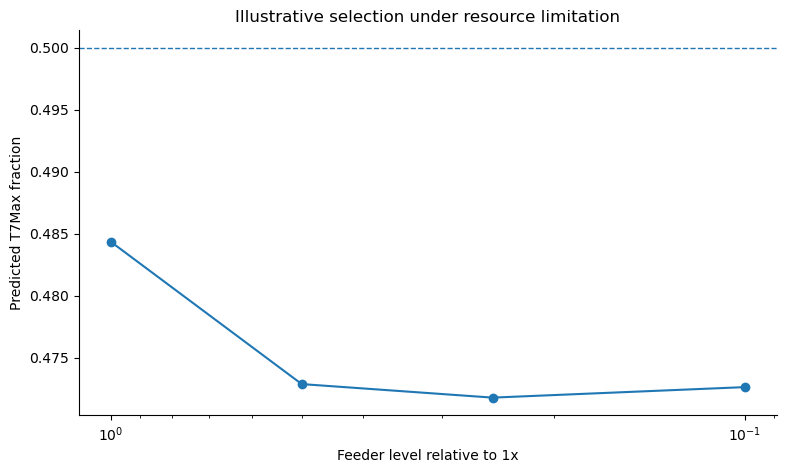

In [8]:
fig, ax = plt.subplots()
ax.plot(competition["feeder_scale"], competition["T7Max_fraction"], marker="o")
ax.axhline(0.5, linestyle="--", linewidth=1)
ax.set_xscale("log")
ax.invert_xaxis()
ax.set_xlabel("Feeder level relative to 1x")
ax.set_ylabel("Predicted T7Max fraction")
ax.set_title("Illustrative selection under resource limitation")
plt.show()


### Interactive competition explorer

Drag the controls to test whether stronger αHL expression is beneficial under different feeder levels.  
The upper panel compares time courses; the lower summary reports the fitness proxy

\[
\mathrm{fitness}=D_{\mathrm{final}}	imes C_{\mathrm{final}}.
\]

A predicted T7Max fraction above 0.5 favors the stronger promoter.

In [9]:
# Interactive T7 versus T7Max competition
promoter_slider = widgets.FloatSlider(
    value=1.55, min=0.5, max=3.0, step=0.05,
    description="T7Max αHL ×", continuous_update=False,
    readout_format=".2f", style={"description_width": "110px"},
    layout=widgets.Layout(width="460px")
)
competition_feeder_slider = widgets.FloatLogSlider(
    value=1.0, base=10, min=-1.3, max=0.3, step=0.05,
    description="Feeder scale", continuous_update=False,
    readout_format=".2f", style={"description_width": "110px"},
    layout=widgets.Layout(width="460px")
)
competition_state = widgets.Dropdown(
    options=[("DNA", "DNA"), ("GFP", "GFP"), ("αHL", "aHL"),
             ("Resource", "resource"), ("Fusion counter", "fusion_counter")],
    value="DNA", description="Plot:",
    style={"description_width": "45px"}
)
competition_output = widgets.Output()

def update_competition(*_):
    feeder_scale = competition_feeder_slider.value
    multiplier = promoter_slider.value
    weak = simulate_genotype(1.0, feeder_scale)
    strong = simulate_genotype(multiplier, feeder_scale)

    weak_fit = weak["DNA"].iloc[-1] * weak["fusion_counter"].iloc[-1]
    strong_fit = strong["DNA"].iloc[-1] * strong["fusion_counter"].iloc[-1]
    denominator = weak_fit + strong_fit
    fraction = strong_fit / denominator if denominator > 0 else np.nan
    state = competition_state.value

    with competition_output:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(9, 4.8))
        ax.plot(weak["time_h"], weak[state], label="T7 (1.0× αHL)", linewidth=2)
        ax.plot(strong["time_h"], strong[state],
                label=f"T7Max ({multiplier:.2f}× αHL)", linewidth=2)
        for boundary in [12, 24, 36, 48, 60, 72]:
            ax.axvline(boundary, linewidth=0.7, alpha=0.25)
        ax.set_xlabel("Time (h)")
        ax.set_ylabel(state)
        ax.set_title(f"Competition trajectories at {feeder_scale:.2f}× feeder")
        ax.legend(frameon=False)
        plt.show()

        verdict = (
            "T7Max favored" if fraction > 0.5
            else "T7 favored" if fraction < 0.5
            else "approximately neutral"
        )
        display(pd.DataFrame({
            "metric": ["T7 fitness proxy", "T7Max fitness proxy",
                       "predicted T7Max fraction", "interpretation"],
            "value": [weak_fit, strong_fit, fraction, verdict]
        }).set_index("metric"))

for control in [promoter_slider, competition_feeder_slider, competition_state]:
    control.observe(update_competition, names="value")

display(widgets.HBox([promoter_slider, competition_feeder_slider, competition_state]))
display(competition_output)
update_competition()


Output()

## Local sensitivity analysis

Normalized local sensitivity is calculated as

\[
S_{ij}=\frac{\partial \ln y_i}{\partial \ln p_j}.
\]


In [10]:
def endpoint(p):
    x = simulate_cycle(p, phi29=True, feeding=True).iloc[-1]
    return np.array([x["DNA"], x["GFP"], x["lipid"], x["fusion_counter"]])

pars = ["k_rep", "k_tx_A", "k_tl_A", "k_fus", "k_R_feed",
        "gamma_rep", "d_R", "division_retention"]
base = endpoint(P)
eps = 0.01
rows = []

for par in pars:
    value = getattr(P, par)
    q = replace(P, **{par: value*(1+eps)})
    s = ((endpoint(q) - base) / base) / eps
    rows.append(dict(parameter=par, DNA=s[0], GFP=s[1],
                     lipid=s[2], fusion_counter=s[3]))

sensitivity = pd.DataFrame(rows).set_index("parameter")
sensitivity.round(3)


,DNA,GFP,lipid,fusion_counter
parameter,,,,
k_rep,0.921,-0.166,0.000,0.000
k_tx_A,-0.104,-0.193,-0.000,0.000
k_tl_A,-0.071,-0.133,-0.000,0.000
k_fus,0.003,0.013,-0.003,0.001
k_R_feed,0.370,0.720,-0.001,0.000
gamma_rep,-0.100,-0.184,0.000,0.000
d_R,-0.078,-0.147,0.000,-0.000
division_retention,1.706,0.024,-0.000,0.000


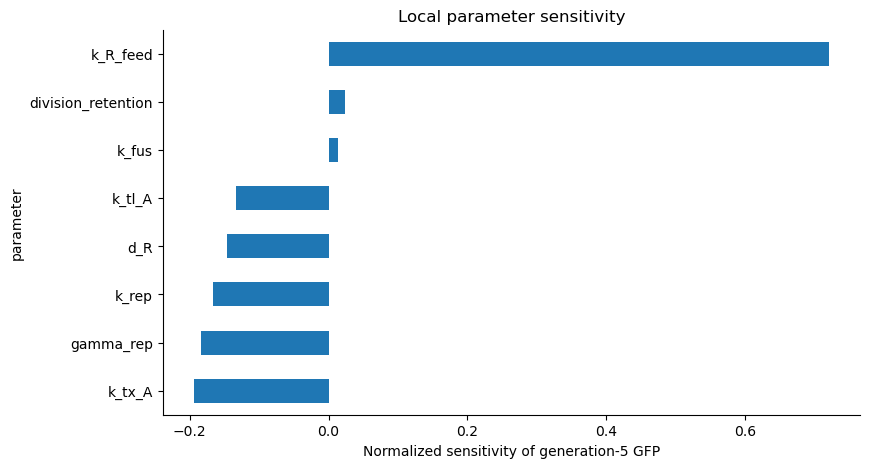

In [11]:
fig, ax = plt.subplots()
sensitivity["GFP"].sort_values().plot(kind="barh", ax=ax)
ax.set_xlabel("Normalized sensitivity of generation-5 GFP")
ax.set_title("Local parameter sensitivity")
plt.show()


### Interactive sensitivity explorer

Choose an endpoint and drag the perturbation slider to see whether the local sensitivity ranking is stable.  
For a truly local analysis, keep the perturbation small (about 1–5%).

In [12]:
# Interactive local sensitivity analysis
sensitivity_endpoint = widgets.Dropdown(
    options=["DNA", "GFP", "lipid", "fusion_counter"],
    value="GFP", description="Endpoint:",
    style={"description_width": "70px"}
)
epsilon_slider = widgets.FloatSlider(
    value=0.01, min=0.005, max=0.20, step=0.005,
    description="Perturbation", continuous_update=False,
    readout_format=".3f", style={"description_width": "85px"},
    layout=widgets.Layout(width="430px")
)
sensitivity_output = widgets.Output()

def calculate_sensitivity(eps):
    base_values = endpoint(P)
    output_rows = []
    for par in pars:
        value = getattr(P, par)
        q = replace(P, **{par: value * (1 + eps)})
        perturbed = endpoint(q)
        s = ((perturbed - base_values) / np.maximum(np.abs(base_values), 1e-12)) / eps
        output_rows.append(dict(
            parameter=par, DNA=s[0], GFP=s[1],
            lipid=s[2], fusion_counter=s[3]
        ))
    return pd.DataFrame(output_rows).set_index("parameter")

def update_sensitivity(*_):
    result = calculate_sensitivity(epsilon_slider.value)
    selected = sensitivity_endpoint.value
    values = result[selected].sort_values()

    with sensitivity_output:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(8.5, 4.8))
        values.plot(kind="barh", ax=ax)
        ax.axvline(0, linewidth=0.8)
        ax.set_xlabel(f"Normalized sensitivity of generation-5 {selected}")
        ax.set_title(
            f"Local sensitivity ({epsilon_slider.value * 100:.1f}% perturbation)"
        )
        plt.show()
        display(result.round(3))

for control in [sensitivity_endpoint, epsilon_slider]:
    control.observe(update_sensitivity, names="value")

display(widgets.HBox([sensitivity_endpoint, epsilon_slider]))
display(sensitivity_output)
update_sensitivity()


Output()

### 📝 Interpretation Questions

**Q1:** Which parameters most strongly affect GFP output?

**Q2:** Why does `k_rep` (replication rate) have low sensitivity?

**Q3:** If you could measure only ONE parameter experimentally, which would be most informative?

**Discussion (3 min):** How does this guide experimental design?

## Parameter-identification requirements

For a defensible quantitative fit, use:

1. Replicate-level plasmid qPCR at generations 3, 4, and 5.
2. αHL and GFP RT-qPCR time courses.
3. GFP fluorescence calibration into protein concentration.
4. αHL protein or pore-number measurements.
5. Fusion fraction or FRET trajectories within each 12-hour generation.
6. Vesicle size distributions before feeding and after extrusion.
7. Lipid and lumen recovery after extrusion.
8. Resource proxies such as ATP, amino acids, active ribosomes, or translation capacity.

Without these data, αHL production, fusion efficiency, and resource replenishment are partly non-identifiable.


## Export trajectories

In [13]:
export = pd.concat(
    [df.assign(condition=name) for name, df in runs.items()],
    ignore_index=True
)
export.to_csv("spudcell_ODE_trajectories.csv", index=False)
summary.to_csv("spudcell_ODE_generation_endpoints.csv", index=False)

print("Wrote spudcell_ODE_trajectories.csv")
print("Wrote spudcell_ODE_generation_endpoints.csv")


Wrote spudcell_ODE_trajectories.csv
Wrote spudcell_ODE_generation_endpoints.csv


## Manuscript-derived inputs represented

- Reactions at 30 °C.
- A 12-hour generation-0 pre-incubation.
- Five generations with 12 hours of feeding/growth each.
- Fresh 30 μL, 2 mM feeder liposomes per generation.
- Mechanical extrusion through a 2 μm membrane.
- Feeder liposomes extruded through 0.4 μm pores and carrying Ni-NTA lipid.
- Whole-genome plasmids typically introduced at 2.5 nM each.
- pREP/Phi29 used for genome replication.
- Measurements at generations 3, 4, and 5.
- Phi29-by-feeding factorial controls.

This is a mechanistic interpretation of the manuscript, not an official model from the authors.


## 🎓 Key Takeaways

### From This Simulation:

1. **Resource Limitation is Central**
   - All processes compete for the same pool
   - Feeder fusion determines maximum growth
   - αHL pores are critical for resource import

2. **Phi29 is Essential**
   - Without Phi29, DNA can't replicate
   - But too much DNA depletes resources
   - Balance is key for synthetic cell growth

3. **αHL Enables Growth**
   - Forms pores for transport
   - Required for feeder fusion
   - Shows strong selection in competition

4. **Extrusion Creates Population Dynamics**
   - Resets quantities each generation
   - Creates division-of-labor between generations
   - Determines population-level fitness

5. **Parameters Have Varying Effects**
   - Some strongly affect GFP (sensitive)
   - Others have minimal impact (robust)
   - Guides experimental design

### For Your Research:
- This model can guide which measurements to prioritize
- Sensitivity analysis reveals what to measure
- Competition analysis predicts strain selection
- Parameter ID section lists required experiments

### Next Steps:
- Modify parameters and explore
- Compare with experimental data
- Extend model with additional processes
- Design new experiments based on insights